In [74]:
import os
os.getcwd()
os.chdir("/Users/xiaolingsundberg/Desktop/Other Data Analysis Projects (for fun)/CovidOnLottery/Data")

In [75]:
# read in stata data useing pd.read_stata() 
import pandas as pd
df = pd.read_stata("powerball_revenues_fl.dta")

# A quick peek

In [76]:
# print the first 5 rows
print(df.head())

   draw_date  revenues  jackpot  covid  covid_cases  monday  wednesday  \
0 2016-05-04   7808170      348      0            0       0          1   
1 2016-05-07  13609322      415      0            0       0          0   
2 2016-05-11   2767830       40      0            0       0          1   
3 2016-05-14   3165299       50      0            0       0          0   
4 2016-05-18   2707620       60      0            0       0          1   

   unempr_adjusted  unempr  jan  ...  sept  oct  nov  year2016  year2017  \
0              4.9     4.6    0  ...     0    0    0         1         0   
1              4.9     4.6    0  ...     0    0    0         1         0   
2              4.9     4.6    0  ...     0    0    0         1         0   
3              4.9     4.6    0  ...     0    0    0         1         0   
4              4.9     4.6    0  ...     0    0    0         1         0   

   year2018  year2019  year2020  year2021  year2022  
0         0         0         0         0   

In [77]:
# check number of rows and columns
print(df.shape)

(639, 27)


In [78]:
# check column names
print(df.columns)

Index(['draw_date', 'revenues', 'jackpot', 'covid', 'covid_cases', 'monday',
       'wednesday', 'unempr_adjusted', 'unempr', 'jan', 'feb', 'mar', 'apr',
       'may', 'jun', 'jul', 'aug', 'sept', 'oct', 'nov', 'year2016',
       'year2017', 'year2018', 'year2019', 'year2020', 'year2021', 'year2022'],
      dtype='object')


In [79]:
# print the last 5 rows
print(df.tail())

     draw_date  revenues  jackpot  covid  covid_cases  monday  wednesday  \
634 2022-02-26   2811939       58      1         1359       0          0   
635 2022-02-28   1503676       65      1         2155       1          0   
636 2022-03-02   1978610       73      1         2333       0          1   
637 2022-03-05   2884397       85      1         1531       0          0   
638 2022-03-07   1544416       90      1         1600       1          0   

     unempr_adjusted  unempr  jan  ...  sept  oct  nov  year2016  year2017  \
634              3.3     3.1    0  ...     0    0    0         0         0   
635              3.3     3.1    0  ...     0    0    0         0         0   
636              3.2     2.7    0  ...     0    0    0         0         0   
637              3.2     2.7    0  ...     0    0    0         0         0   
638              3.2     2.7    0  ...     0    0    0         0         0   

     year2018  year2019  year2020  year2021  year2022  
634         0     

In [80]:
# check variable data types
print(df.dtypes)

draw_date          datetime64[ns]
revenues                    int32
jackpot                     int16
covid                        int8
covid_cases                 int32
monday                       int8
wednesday                    int8
unempr_adjusted           float64
unempr                    float64
jan                          int8
feb                          int8
mar                          int8
apr                          int8
may                          int8
jun                          int8
jul                          int8
aug                          int8
sept                         int8
oct                          int8
nov                          int8
year2016                     int8
year2017                     int8
year2018                     int8
year2019                     int8
year2020                     int8
year2021                     int8
year2022                     int8
dtype: object


In [81]:
# check missing values
print(df.isnull().sum())

draw_date          0
revenues           0
jackpot            0
covid              0
covid_cases        0
monday             0
wednesday          0
unempr_adjusted    0
unempr             0
jan                0
feb                0
mar                0
apr                0
may                0
jun                0
jul                0
aug                0
sept               0
oct                0
nov                0
year2016           0
year2017           0
year2018           0
year2019           0
year2020           0
year2021           0
year2022           0
dtype: int64


No missing values

# Data Exploration
## Summary Statistics and Visualization

In [82]:
# summary statistics - numerical 
print(df.describe())

                           draw_date      revenues     jackpot       covid  \
count                            639  6.390000e+02  639.000000  639.000000   
mean   2019-05-18 11:49:51.549295872  3.818770e+06  168.948357    0.374022   
min              2016-05-04 00:00:00  1.439134e+06   20.000000    0.000000   
25%              2017-11-13 00:00:00  2.568074e+06   70.000000    0.000000   
50%              2019-05-25 00:00:00  3.082460e+06  130.000000    0.000000   
75%              2020-12-03 12:00:00  3.768981e+06  229.000000    1.000000   
max              2022-03-07 00:00:00  3.812189e+07  750.000000    1.000000   
std                              NaN  3.040242e+06  132.861274    0.484248   

        covid_cases      monday   wednesday  unempr_adjusted      unempr  \
count    639.000000  639.000000  639.000000       639.000000  639.000000   
mean    3197.406886    0.043818    0.474178         4.733959    4.718936   
min        0.000000    0.000000    0.000000         2.700000    2.500

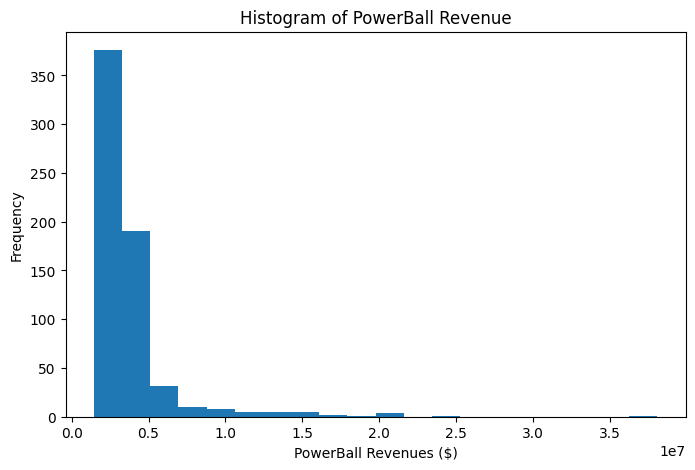

In [83]:
# histogram - show revenue distribution 
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["revenues"],bins=20)
plt.xlabel("PowerBall Revenues ($)")
plt.ylabel("Frequency")
plt.title("Histogram of PowerBall Revenue")
plt.show()


Conclusion: The revenues distribution is heavily right-skewed with most observations concentrated in the lower revenue range roughly between $2.5 million and $5.0 million and there are a few much larger values that create a long right tail. A log transformation may be considered.

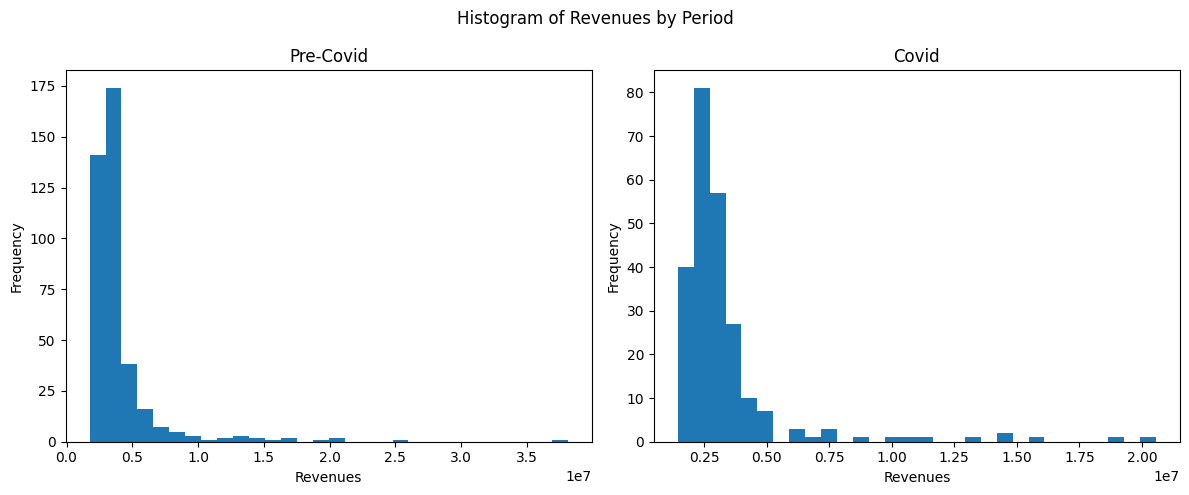

In [191]:
# a histogram of revenues by periods for comparison

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pre-Covid
axes[0].hist(df.loc[df["covid"] == 0, "revenues"], bins=30)
axes[0].set_title("Pre-Covid")
axes[0].set_xlabel("Revenues")
axes[0].set_ylabel("Frequency")

# Covid
axes[1].hist(df.loc[df["covid"] == 1, "revenues"], bins=30)
axes[1].set_title("Covid")
axes[1].set_xlabel("Revenues")
axes[1].set_ylabel("Frequency")

plt.suptitle("Histogram of Revenues by Period")
plt.tight_layout()
plt.show()

Revenues data in both periods appear to be right skewed. 

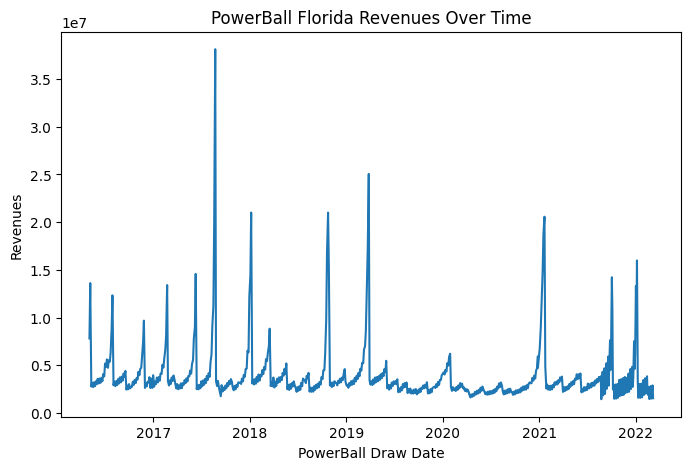

In [84]:
# line plot - show how revenues change over time 
plt.figure(figsize=(8,5))
plt.plot(df["draw_date"],df["revenues"])
plt.xlabel("PowerBall Draw Date")
plt.ylabel("Revenues")
plt.title("PowerBall Florida Revenues Over Time")
plt.show()

Conclusion: The line plot shows a clear decline in PowerBall revenues during the Covid period, particularly in 2020, before recovery afterward. There seems to be a revenue outlier in late 2017 exceeding $35 million.

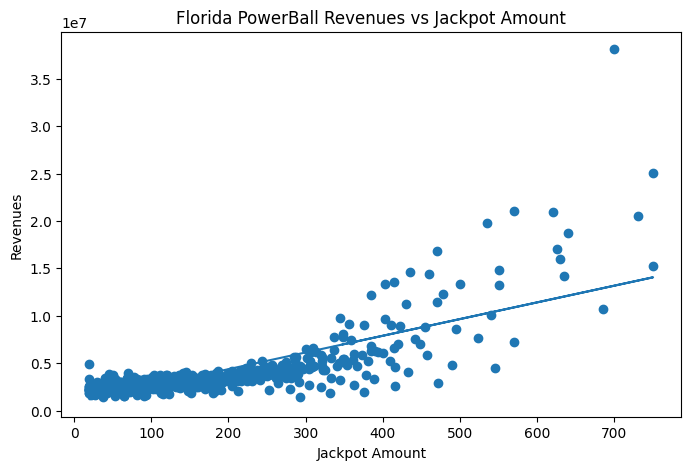

In [85]:
# scatter plot - show how revenues changes as the amount of jackpot changes
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))
plt.scatter(df["jackpot"],df["revenues"])

m,b = np.polyfit(df["jackpot"], df["revenues"],1)
plt.plot(df["jackpot"], m*df["jackpot"]+b)

plt.xlabel("Jackpot Amount")
plt.ylabel("Revenues")
plt.title("Florida PowerBall Revenues vs Jackpot Amount")
plt.show()

Conclusion: The scatter plot suggests a positive association between the jackpot amount and revenues: as the jackpot amount increases, revenues tend to increase. The relation is roughly linear, although as the jackpot amount gets larger, the range of the revenues spreads wider, suggesting that variability increases at higher jackpot amounts. There is one extremely large revenue outlier over $30 million associated with a jackpot close to $700 million.

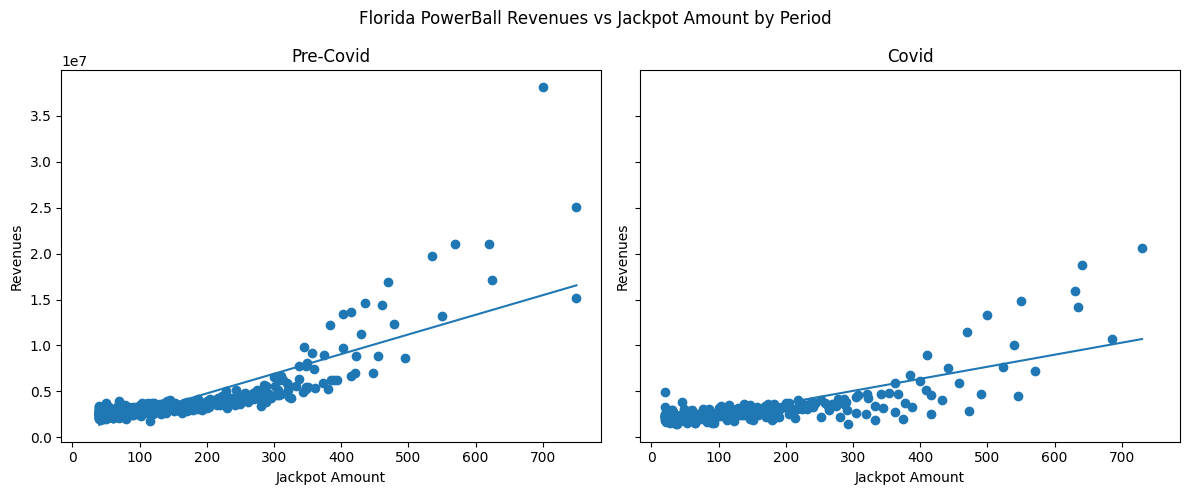

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# set the same scale for both scatter plots and regression lines 
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Pre-Covid
x_pre = df.loc[df["covid"] == 0, "jackpot"] # locate the covid==0 rows, and take the corresponding jackpot 
y_pre = df.loc[df["covid"] == 0, "revenues"] # locate the covid==0 rows, and take the corresponding revenues 

axes[0].scatter(x_pre, y_pre)
slope_pre, intercept_pre = np.polyfit(x_pre, y_pre, 1)
x_pre_sorted = np.sort(x_pre)
axes[0].plot(x_pre_sorted, slope_pre * x_pre_sorted + intercept_pre)
axes[0].set_title("Pre-Covid")
axes[0].set_xlabel("Jackpot Amount")
axes[0].set_ylabel("Revenues")

# Covid
x_covid = df.loc[df["covid"] == 1, "jackpot"]
y_covid = df.loc[df["covid"] == 1, "revenues"]

axes[1].scatter(x_covid, y_covid)
slope_covid, intercept_covid = np.polyfit(x_covid, y_covid, 1)
x_covid_sorted = np.sort(x_covid)
axes[1].plot(x_covid_sorted, slope_covid * x_covid_sorted + intercept_covid)
axes[1].set_title("Covid")
axes[1].set_xlabel("Jackpot Amount")
axes[1].set_ylabel("Revenues")

plt.suptitle("Florida PowerBall Revenues vs Jackpot Amount by Period")
plt.tight_layout() # adjust spacing automatically (e.g., prevents title overlapping..)
plt.show()

The side by side revenue scatter plots comparison between pre_covid and covid periods reveal that the average revenue is lower during covid period. 

In [86]:
# compare revenues between Pre-covid and Covid periods 
# define Covid period: any time after March 03, 2020 (first case recorded in the United States)
df["covid_period"] = np.where(
    df["draw_date"] >= pd.Timestamp("2020-03-04"),
    1,
    0
)

<Figure size 800x500 with 0 Axes>

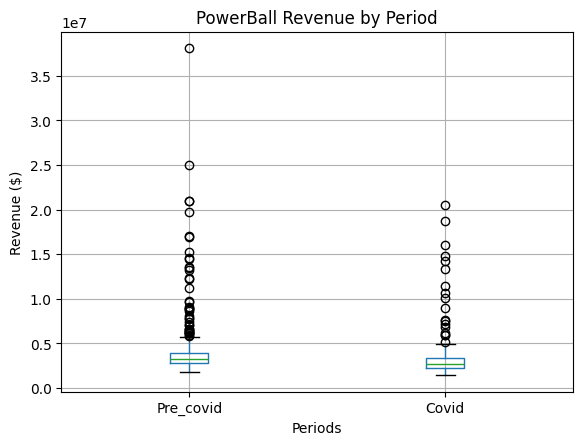

In [ ]:
# boxplot 
# define a new variable "covid_label" - using map() -  covid_period =0 as "Pre_covid" and =1 as "Covid"
# pre_covid: May 04,2016 - March 03,2020; covid: March 04,2020 - March 07, 2022 
# May 04, 2016 is the earliest date lottery information could be found online and March 07 is the day this project began.
df["covid_label"] = pd.Categorical(
    df["covid_period"].map({0:"Pre_covid", 1:"Covid"}),
    categories=["Pre_covid", "Covid"],
    ordered=True
) # used pd.Categorical() to treat "covid_label" as categorical and not ordinal; ordered=True ensures Pre_covid is in front of Covid

plt.figure(figsize=(8,5))
df.boxplot(column = "revenues", by="covid_label")

plt.title("PowerBall Revenue by Period")
plt.suptitle("") # to clean the auto title 
plt.xlabel("Periods")
plt.ylabel("Revenue ($)")
plt.show()


Conclusion: The boxplot shows a fairly similar PowerBall median revenue for both Pre_covid and Covid periods with the Pre_covid period slightly higher. The graph also shows that both periods have high revenue outliers. There is one extremely large revenue outlier in the Pre_covid period. This may be related to a very large jackpot, and can be further examined. 

In [100]:
# correlation coefficient tests
# Pearson's p and Spearman Rank Order Correlation 
print("Pearson's Correlation:")
print(df[["jackpot","revenues"]].corr(method="pearson"))

print("Spearman's Correlation:")
print(df[["jackpot","revenues"]].corr(method="spearman"))

Pearson's Correlation:
           jackpot  revenues
jackpot   1.000000  0.770158
revenues  0.770158  1.000000
Spearman's Correlation:
           jackpot  revenues
jackpot   1.000000  0.754274
revenues  0.754274  1.000000


Both the Pearson and Spearman correlations show a strong positive association between revenues and jackpot amount, suggesting that the positive relationship is stable, even though the data still show skewness and outliers.

In [136]:
# summary statistics before and after covid
print("PowerBall Revenue Before Covid:")
print(df.loc[df["covid"] == 0, ["revenues"]].describe())

print("PowerBall Revenue During Covid:")
print(df.loc[df["covid"] == 1, ["revenues"]].describe())

PowerBall Revenue Before Covid:
           revenues
count  4.000000e+02
mean   4.107568e+06
std    3.274574e+06
min    1.751987e+06
25%    2.795619e+06
50%    3.269741e+06
75%    3.966556e+06
max    3.812189e+07
PowerBall Revenue During Covid:
           revenues
count  2.390000e+02
mean   3.335426e+06
std    2.535024e+06
min    1.439134e+06
25%    2.226230e+06
50%    2.709309e+06
75%    3.391364e+06
max    2.056841e+07


Conclusion: PowerBall revenues were lower during the Covid period. The mean declined from about $4.1 million in the Pre_covid period to $3.3 million during Covid, while the median declined from about $3.3 million to $2.7 million. Furthermore, the standard deviation is lower during Covid, indicating less variation in revenues during that period. This suggests there were fewer or less extreme high-revenue observations during Covid.

# Outlier Detection for Revenues
### 3 standard deviation rule 
### Hampel Identifier
### IQR - already done above

In [106]:
# 3 standard deviation rule 
mean_revenue = df["revenues"].mean()
std_revenue = df["revenues"].std()

lower_3std = mean_revenue - 3*std_revenue
upper_3std = mean_revenue + 3*std_revenue

outliers_std = df[(df["revenues"]<lower_3std)|(df["revenues"]>upper_3std)]

print("3 Standard Deviation Rule:")
print("Lower Bound:", lower_3std)
print("Upper Bound:", upper_3std)
print("Number of Outliers", outliers_std.shape[0])

print(outliers_std[["draw_date","jackpot","revenues"]])

3 Standard Deviation Rule:
Lower Bound: -5301954.524133937
Upper Bound: 12939495.2252294
Number of Outliers 19
     draw_date  jackpot  revenues
1   2016-05-07      415  13609322
84  2017-02-22      403  13402222
115 2017-06-10      435  14571695
135 2017-08-19      535  19784137
136 2017-08-23      700  38121888
174 2018-01-03      460  14426212
175 2018-01-06      570  21000850
257 2018-10-20      470  16881580
258 2018-10-24      620  20998301
259 2018-10-27      750  15218359
300 2019-03-20      550  13206588
301 2019-03-23      625  17092799
302 2019-03-27      750  25053314
490 2021-01-13      550  14818294
491 2021-01-16      640  18767788
492 2021-01-20      730  20568410
571 2021-10-02      635  14220380
610 2022-01-01      500  13299894
612 2022-01-05      630  15981253


19 rows of outliers are detected. Since the outlier proportion is about 3% (above the 1% 3std rule threshold), a Hampel comparison is considered.

In [117]:
# hampel identifier 
    ## the hampel use median and MAD is the core part
# MAD:
    ## first calculate the absolute deviation: abs(revenues - median_revenue)
    ## then take the median of those absolute deviations

# Hampel score:
    ## absolute deviation divided by (1.4826 * MAD)
median_revenue = df["revenues"].median()

MAD = np.median(np.abs(df["revenues"]-median_revenue))

hampel_score = np.abs(df["revenues"]-median_revenue)/(1.4826*MAD)

outliers_hampel = df[hampel_score>3]

print("Hample Outliers:")
print("Median:", median_revenue)
print("MAD:", MAD)
print("Number of Outliers:", outliers_hampel.shape[0])

print(outliers_hampel[["draw_date","jackpot","revenues"]])

Hample Outliers:
Median: 3082460.0
MAD: 578479.0
Number of Outliers: 58
     draw_date  jackpot  revenues
0   2016-05-04      348   7808170
1   2016-05-07      415  13609322
23  2016-07-23      390   6267968
24  2016-07-27      422   8896557
25  2016-07-30      478  12323899
57  2016-11-19      320   5910739
58  2016-11-23      359   7442138
59  2016-11-26      403   9676470
81  2017-02-11      285   5698628
82  2017-02-15      310   6625618
83  2017-02-18      349   8052517
84  2017-02-22      403  13402222
113 2017-06-03      337   7785283
114 2017-06-07      375   8988990
115 2017-06-10      435  14571695
132 2017-08-09      307   6182888
133 2017-08-12      356   9128994
134 2017-08-16      430  11196495
135 2017-08-19      535  19784137
136 2017-08-23      700  38121888
171 2017-12-23      300   6528007
172 2017-12-27      337   6346328
173 2017-12-30      384  12211244
174 2018-01-03      460  14426212
175 2018-01-06      570  21000850
193 2018-03-10      385   6290742
194 2018-0

Hampel detected 58 outlier rows, which is substantially higher than the 3 standard deviation rule. Given the right-skewed distribution of the data, this suggests that the 3 standard deviation rule may be influenced by extreme values because it depends on the mean and standard deviation. The IQR method will be considered next.

In [126]:
# IQR
Q1 = df["revenues"].quantile(0.25)
Q3 = df["revenues"].quantile(0.75)
IQR = Q3-Q1

lower_IQR = Q1 - 1.5*IQR
upper_IQR = Q3 + 1.5*IQR

outliers_IQR = df[(df["revenues"]<lower_IQR)|(df["revenues"]>upper_IQR)]

print("Interquartile Range (IQR) Outliers:")
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_IQR)
print("Upper Bound:", upper_IQR)
print("Number of Outliers:", outliers_IQR.shape[0])

print(outliers_IQR[["draw_date","jackpot","revenues"]])


Interquartile Range (IQR) Outliers:
Q1: 2568074.0
Q3: 3768981.0
IQR: 1200907.0
Lower Bound: 766713.5
Upper Bound: 5570341.5
Number of Outliers: 61
     draw_date  jackpot  revenues
0   2016-05-04      348   7808170
1   2016-05-07      415  13609322
19  2016-07-09      288   5612586
23  2016-07-23      390   6267968
24  2016-07-27      422   8896557
..         ...      ...       ...
607 2021-12-25      441   7518389
609 2021-12-29      400   6116661
610 2022-01-01      500  13299894
611 2022-01-03      540  10055296
612 2022-01-05      630  15981253

[61 rows x 3 columns]


IQR detected 61 outliers, which is very similar to the Hampel identifier (58). This suggests that for this right skewed variable, the 3 std method is influenced by large outliers. Therefore the more robust methods IQR and Hampel appear to be more appropriate for detecting outliers. 
This means that the data are not well behaved enough to rely on the mean-based rule; therefore, when modeling, a more robust approach is preferred such as checking "log revenues."

# Preparation for Building Regression Models
### Check correlation between variables (unemployment rate and adjusted unemployment rate)
### Create new variables (lagjackpot, interaction terms)

In [143]:
# check the correlation of variables to avoid multicollinearity 
print("Correlation Between Unemployment Rate and Adjusted Unemployment Rate")
print(df[["unempr_adjusted","unempr"]].corr())

Correlation Between Unemployment Rate and Adjusted Unemployment Rate
                 unempr_adjusted    unempr
unempr_adjusted         1.000000  0.994629
unempr                  0.994629  1.000000


Since the unemployment rate has extremely high correlation with the adjusted unemployment rate, use only one in the model.

In [153]:
# sort by draw_date before creating lag variables
df = df.sort_values("draw_date").reset_index(drop=True)

# create lagjackpot so each row uses the previous drawing's jackpot amount
df["lagjackpot"] = df["jackpot"].shift(1)

In [154]:
# create interaction terms: lagjackpot_covid, unempr_covid, and lagjackpot_unempr
df["lagjackpot_covid"] = df["lagjackpot"]*df["covid"]
df["unempr_covid"] = df["unempr"]*df["covid"]
df["lagjackpot_unempr"] = df["lagjackpot"]*df["unempr"]

In [161]:
# create a lagjackpot squared term to allow nonlinear effect of jackpot on revenue but ended up not using it
df["lagjackpot_squared"] = df["lagjackpot"]**2

In [155]:
# use log transformation to reduce the skewness of the data
df["log_revenue"] = np.log(df["revenues"])

In [156]:
# create year dummies 
df["year"] = np.nan

df.loc[df["year2016"] == 1, "year"] = 2016
df.loc[df["year2017"] == 1, "year"] = 2017
df.loc[df["year2018"] == 1, "year"] = 2018
df.loc[df["year2019"] == 1, "year"] = 2019
df.loc[df["year2020"] == 1, "year"] = 2020
df.loc[df["year2021"] == 1, "year"] = 2021
df.loc[df["year2022"] == 1, "year"] = 2022

# Build Three Regression Models
#### Model 1: revenues = covid + lagjackpot + unempr + monday + wednesday 
#### Model 2: revenues = covid + lagjackpot + lagjackpot_covid + unempr + unempr_covid + monday + wednesday 
#### Model 3: revenues = covid + lagjackpot + lagjackpot_covid + unempr + unempr_covid + lagjackpot_unempr + monday + wednesday 

In [158]:
# check variables again 
print(df.columns)

Index(['draw_date', 'revenues', 'jackpot', 'covid', 'covid_cases', 'monday',
       'wednesday', 'unempr_adjusted', 'unempr', 'jan', 'feb', 'mar', 'apr',
       'may', 'jun', 'jul', 'aug', 'sept', 'oct', 'nov', 'year2016',
       'year2017', 'year2018', 'year2019', 'year2020', 'year2021', 'year2022',
       'covid_period', 'covid_label', 'lagjackpot', 'lagjackpot_covid',
       'unempr_covid', 'lagjackpot_unempr', 'lagjackpot_squared',
       'lag_jackpot', 'log_revenue', 'year'],
      dtype='object')


In [178]:
# Model 1
# since lagjackpot was created using "shift1", the first row may be empty and it needs to be dropped 

model_vars_1 = ["revenues", "covid", "lagjackpot", "unempr", "monday", "wednesday"]
df1 = df[model_vars_1].dropna()

import statsmodels.api as sm

# choose predictors and target variable
X1 = df1[["covid","lagjackpot","unempr","monday","wednesday"]]
X1 = sm.add_constant(X1)
y = df1["revenues"]

# fit the model
model1 = sm.OLS(y,X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:               revenues   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     86.81
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           1.97e-69
Time:                        14:49:51   Log-Likelihood:                -10261.
No. Observations:                 638   AIC:                         2.053e+04
Df Residuals:                     632   BIC:                         2.056e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.717e+06   2.85e+05      6.035      0.0

In [182]:
# Model 2
# since lagjackpot was created using "shift1", the first row may be empty and it needs to be dropped 

model_vars_2 = ["revenues", "covid", "lagjackpot", "lagjackpot_covid","unempr", "unempr_covid","monday", "wednesday"]
df2 = df[model_vars_2].dropna()

import statsmodels.api as sm

# choose predictors and target variable
X2 = df2[["covid","lagjackpot","lagjackpot_covid","unempr","unempr_covid","monday","wednesday"]]
X2 = sm.add_constant(X2)
y = df2["revenues"]

# fit the model
model2 = sm.OLS(y,X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:               revenues   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     64.79
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           4.01e-70
Time:                        14:53:27   Log-Likelihood:                -10255.
No. Observations:                 638   AIC:                         2.053e+04
Df Residuals:                     630   BIC:                         2.056e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             3.124e+05   6.82e+05  

In [187]:
# Model 3
# since lagjackpot was created using "shift1", the first row may be empty and it needs to be dropped 

model_vars_3 = ["revenues", "covid", "lagjackpot", "lagjackpot_covid","unempr", "unempr_covid","lagjackpot_unempr","monday", "wednesday"]
df3 = df[model_vars_3].dropna()

import statsmodels.api as sm

# choose predictors and target variable
X3 = df3[["covid","lagjackpot","lagjackpot_covid","unempr","unempr_covid","lagjackpot_unempr","monday","wednesday"]]
X3 = sm.add_constant(X3)
y = df3["revenues"]

# fit the model
model3 = sm.OLS(y,X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:               revenues   R-squared:                       0.423
Model:                            OLS   Adj. R-squared:                  0.416
Method:                 Least Squares   F-statistic:                     57.65
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           3.05e-70
Time:                        14:56:51   Log-Likelihood:                -10253.
No. Observations:                 638   AIC:                         2.052e+04
Df Residuals:                     629   BIC:                         2.056e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.086e+06   7.64e+0

# Compare the models 
### AIC, BIC, Adjusted-R^2

In [211]:
import pandas as pd

model_comparison_table = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "n_obs": [model1.nobs, model2.nobs, model3.nobs],
    "R_squared": [model1.rsquared, model2.rsquared, model3.rsquared],
    "Adj_R_squared": [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj],
    "AIC": [model1.aic, model2.aic, model3.aic],
    "BIC": [model1.bic, model2.bic, model3.bic]
})

model_comparison_table

,Model,n_obs,R_squared,Adj_R_squared,AIC,BIC
0,Model 1,638.0,0.407159,0.402469,20534.696967,20561.446997
1,Model 2,638.0,0.418584,0.412124,20526.281552,20561.948258
2,Model 3,638.0,0.423054,0.415716,20523.357741,20563.482785


Among the three candidate models, Model 3 achieved the highest adjusted R-squared and the lowest AIC, indicating the best overall fit. Although Model 1 had the lowest BIC and is therefore the most parsimonious specification, Model 3 was selected as the final model because it provides the strongest fit to the data.

# Post-estimation inference for the final model

In [217]:
import pandas as pd
import numpy as np

def linear_combination_test(results, weights_dict, label="Quantity"):
    """
    results: fitted statsmodels OLS results object
    weights_dict: dictionary assigning weights to coefficients
    """
    parameter_names = results.params.index
    weight_vector = pd.Series(0.0, index=parameter_names)

    for name, weight in weights_dict.items():
        weight_vector[name] = weight

    test_result = results.t_test(weight_vector.values)

    estimate = test_result.effect.item()
    standard_error = test_result.sd.item()
    t_value = test_result.tvalue.item()
    p_value = test_result.pvalue.item()
    ci_lower, ci_upper = test_result.conf_int()[0]

    output = pd.DataFrame({
        "Quantity": [label],
        "Estimate": [estimate],
        "Std_Error": [standard_error],
        "t_value": [t_value],
        "p_value": [p_value],
        "CI_Lower_95": [ci_lower],
        "CI_Upper_95": [ci_upper]
    })

    return output

# sample means used in Model 3 interpretation
mean_jackpot_3 = df3["lagjackpot"].mean()
mean_unempr_3 = df3["unempr"].mean()
mean_lagjackpot_unempr_3 = df3["lagjackpot_unempr"].mean()
mean_monday_3 = df3["monday"].mean()
mean_wednesday_3 = df3["wednesday"].mean()

# 1) predicted mean revenue before COVID
predicted_mean_before_weights = {
    "const": 1,
    "lagjackpot": mean_jackpot_3,
    "unempr": mean_unempr_3,
    "lagjackpot_unempr": mean_lagjackpot_unempr_3,
    "monday": mean_monday_3,
    "wednesday": mean_wednesday_3
}

predicted_mean_before_result = linear_combination_test(
    model3,
    predicted_mean_before_weights,
    label="Predicted mean revenue before COVID"
)

# 2) predicted mean revenue during COVID
predicted_mean_during_weights = {
    "const": 1,
    "covid": 1,
    "lagjackpot": mean_jackpot_3,
    "lagjackpot_covid": mean_jackpot_3,
    "unempr": mean_unempr_3,
    "unempr_covid": mean_unempr_3,
    "lagjackpot_unempr": mean_lagjackpot_unempr_3,
    "monday": mean_monday_3,
    "wednesday": mean_wednesday_3
}

predicted_mean_during_result = linear_combination_test(
    model3,
    predicted_mean_during_weights,
    label="Predicted mean revenue during COVID"
)


# 3) difference in predicted mean revenue
difference_in_predicted_mean_weights = {
    "covid": 1,
    "lagjackpot_covid": mean_jackpot_3,
    "unempr_covid": mean_unempr_3
}

difference_in_predicted_mean_result = linear_combination_test(
    model3,
    difference_in_predicted_mean_weights,
    label="Difference in predicted mean revenue (during - before)"
)

# 4) mean marginal effect of lagjackpot before COVID
marginal_effect_lagjackpot_before_weights = {
    "lagjackpot": 1,
    "lagjackpot_unempr": mean_unempr_3
}

marginal_effect_lagjackpot_before_result = linear_combination_test(
    model3,
    marginal_effect_lagjackpot_before_weights,
    label="Mean marginal effect of lagjackpot before COVID"
)

# 5) mean marginal effect of lagjackpot during COVID
marginal_effect_lagjackpot_during_weights = {
    "lagjackpot": 1,
    "lagjackpot_covid": 1,
    "lagjackpot_unempr": mean_unempr_3
}

marginal_effect_lagjackpot_during_result = linear_combination_test(
    model3,
    marginal_effect_lagjackpot_during_weights,
    label="Mean marginal effect of lagjackpot during COVID"
)

# 6) difference in mean marginal effect of lagjackpot
difference_in_marginal_effect_lagjackpot_weights = {
    "lagjackpot_covid": 1
}

difference_in_marginal_effect_lagjackpot_result = linear_combination_test(
    model3,
    difference_in_marginal_effect_lagjackpot_weights,
    label="Difference in mean marginal effect of lagjackpot"
)

# 7) mean marginal effect of unempr before COVID
marginal_effect_unempr_before_weights = {
    "unempr": 1,
    "lagjackpot_unempr": mean_jackpot_3
}

marginal_effect_unempr_before_result = linear_combination_test(
    model3,
    marginal_effect_unempr_before_weights,
    label="Mean marginal effect of unempr before COVID"
)

# 8) mean marginal effect of unempr during COVID
marginal_effect_unempr_during_weights = {
    "unempr": 1,
    "unempr_covid": 1,
    "lagjackpot_unempr": mean_jackpot_3
}

marginal_effect_unempr_during_result = linear_combination_test(
    model3,
    marginal_effect_unempr_during_weights,
    label="Mean marginal effect of unempr during COVID"
)

# 9) difference in mean marginal effect of unempr
difference_in_marginal_effect_unempr_weights = {
    "unempr_covid": 1
}

difference_in_marginal_effect_unempr_result = linear_combination_test(
    model3,
    difference_in_marginal_effect_unempr_weights,
    label="Difference in mean marginal effect of unempr"
)

# combine all post-estimation results into one table
model3_post_estimation_table = pd.concat([
    predicted_mean_before_result,
    predicted_mean_during_result,
    difference_in_predicted_mean_result,
    marginal_effect_lagjackpot_before_result,
    marginal_effect_lagjackpot_during_result,
    difference_in_marginal_effect_lagjackpot_result,
    marginal_effect_unempr_before_result,
    marginal_effect_unempr_during_result,
    difference_in_marginal_effect_unempr_result
], ignore_index=True)

model3_post_estimation_table

,Quantity,Estimate,Std_Error,t_value,p_value,CI_Lower_95,CI_Upper_95
0,Predicted mean revenue before COVID,4.253378e+06,183418.759084,23.189438,1.909606e-86,3.893191e+06,4.613565e+06
1,Predicted mean revenue during COVID,3.433503e+06,173914.624482,19.742460,7.020338e-68,3.091979e+06,3.775026e+06
2,Difference in predicted mean revenue (during -...,-8.198753e+05,256571.922704,-3.195499,1.465754e-03,-1.323717e+06,-3.160341e+05
3,Mean marginal effect of lagjackpot before COVID,1.704031e+04,1044.679146,16.311522,3.815150e-50,1.498883e+04,1.909179e+04
4,Mean marginal effect of lagjackpot during COVID,1.179024e+04,1086.745944,10.849119,2.955045e-25,9.656146e+03,1.392433e+04
5,Difference in mean marginal effect of lagjackpot,-5.250071e+03,1502.485449,-3.494258,5.087685e-04,-8.200566e+03,-2.299577e+03
6,Mean marginal effect of unempr before COVID,3.463129e+05,167109.318818,2.072373,3.863746e-02,1.815320e+04,6.744726e+05
7,Mean marginal effect of unempr during COVID,8.633264e+04,66704.448939,1.294256,1.960519e-01,-4.465773e+04,2.173230e+05
8,Difference in mean marginal effect of unempr,-2.599803e+05,179682.911072,-1.446884,1.484277e-01,-6.128312e+05,9.287074e+04


Conclusion: The post-estimation results for Model 3 indicate that, evaluated at the sample means, average Florida PowerBall revenue was significantly lower during the COVID period than in the pre-COVID period. The model predicts mean revenue of approximately $4.25 million before COVID and $3.43 million during COVID. The estimated difference is about -$819,875 per drawing, and this difference is statistically significant (p = 0.0015).

The results also show that the responsiveness of revenue to jackpot size weakened during COVID. Before COVID, a $1 million increase in the lagged jackpot amount was associated with an average revenue increase of about $17,040, while during COVID the corresponding effect was about $11,790. The estimated change in this marginal effect is approximately -$5,250, which is statistically significant (p = 0.0005).

By contrast, although the estimated marginal effect of the unemployment rate declines from about $346,313 before COVID to about $86,333 during COVID, the estimated difference of approximately -$259,980 is not statistically significant (p = 0.148). Therefore, the evidence from Model 3 suggests that Florida PowerBall revenues fell during COVID and became less responsive to jackpot size, while there is not sufficient statistical evidence to conclude that the effect of unemployment on revenues changed between the two periods.

These results may reflect a change in aggregate spending behavior during the pandemic, in the sense that lottery-related revenue was lower and less responsive to jackpot increases during COVID. However, because this thesis uses state-level aggregate data rather than individual-level data, it cannot identify how any one individual changed spending behavior directly. The analysis can only show overall state-level trends and changes in the relationships between revenues and the explanatory variables across periods.